# Data exploratory

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import plotly.graph_objs as go 
import plotly.offline as py 
import math
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

In [44]:
print("\nTransaction features: \n")
df_txs_features = pd.read_csv("dataset/txs_features.csv")
df_txs_features

print("\nTransaction classes: \n")
df_txs_classes = pd.read_csv("dataset/txs_classes.csv")
df_txs_classes

print("\nTransaction-Transaction edgelist: \n")
df_txs_edgelist = pd.read_csv("dataset/txs_edgelist.csv")
df_txs_edgelist


Transaction features: 



,txId,Time step,Local_feature_1,Local_feature_2,Local_feature_3,Local_feature_4,Local_feature_5,Local_feature_6,Local_feature_7,Local_feature_8,...,in_BTC_min,in_BTC_max,in_BTC_mean,in_BTC_median,in_BTC_total,out_BTC_min,out_BTC_max,out_BTC_mean,out_BTC_median,out_BTC_total
0,3321,1,-0.169615,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.160199,...,0.534072,0.534072,0.534072,0.534072,0.534072,1.668990e-01,0.367074,0.266986,0.266986,0.533972
1,11108,1,-0.137586,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.127429,...,5.611878,5.611878,5.611878,5.611878,5.611878,5.861940e-01,5.025584,2.805889,2.805889,5.611778
2,51816,1,-0.170103,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.160699,...,0.456608,0.456608,0.456608,0.456608,0.456608,2.279902e-01,0.228518,0.228254,0.228254,0.456508
3,68869,1,-0.114267,-0.184668,-1.201369,0.028105,-0.043875,-0.113002,0.547008,-0.161652,...,0.308900,8.000000,3.102967,1.000000,9.308900,1.229000e+00,8.079800,4.654400,4.654400,9.308800
4,89273,1,5.202107,-0.210553,-1.756361,-0.121970,260.090707,-0.113002,-0.061584,5.335864,...,852.164680,852.164680,852.164680,852.164680,852.164680,1.300000e-07,41.264036,0.065016,0.000441,852.164680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203764,158304003,49,-0.165622,-0.139563,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.156113,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
203765,158303998,49,-0.167040,-0.139563,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.157564,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
203766,158303966,49,-0.167040,-0.139563,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.157564,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
203767,161526077,49,-0.172212,-0.139573,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.162856,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Transaction classes: 



,txId,class
0,3321,3
1,11108,3
2,51816,3
3,68869,2
4,89273,2
...,...,...
203764,158304003,3
203765,158303998,3
203766,158303966,3
203767,161526077,3



Transaction-Transaction edgelist: 



,txId1,txId2
0,230425980,5530458
1,232022460,232438397
2,230460314,230459870
3,230333930,230595899
4,232013274,232029206
...,...,...
234350,158365409,157930723
234351,188708874,188708879
234352,157659064,157659046
234353,87414554,106877725


In [45]:
df_txs_features.insert(loc=2, column='class', value=df_txs_classes['class'])
df_txs_features['class'].value_counts()

class
3    157205
2     42019
1      4545
Name: count, dtype: int64

<BarContainer object of 3 artists>

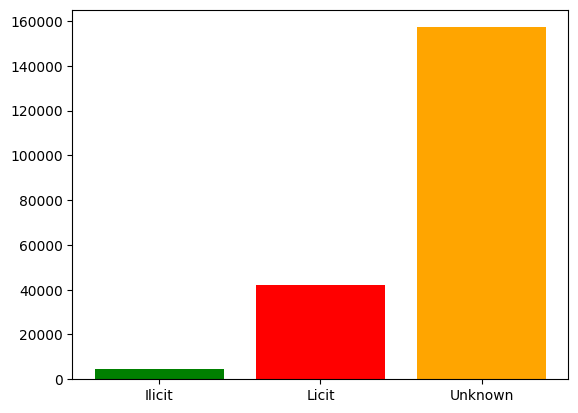

In [46]:
txs_by_class = df_txs_features.groupby('class').count()
plt.bar(['Ilicit', 'Licit', 'Unknown'], txs_by_class['txId'].values, color=['g', 'r', 'orange'] )

Text(0.5, 1.0, 'Number of transactions by time step')

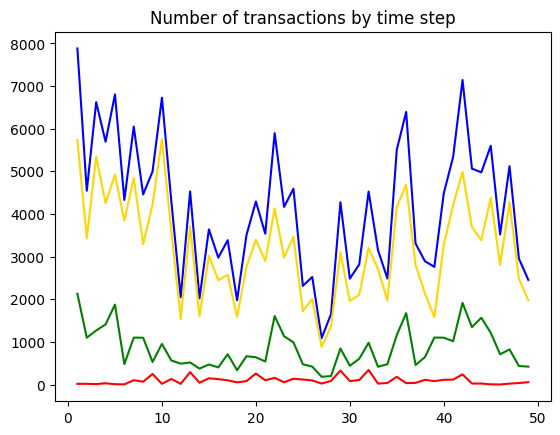

In [47]:
total_txs = df_txs_features.groupby('Time step').count()
illicit_txs = df_txs_features[df_txs_features['class']==1].groupby('Time step').count()
licit_txs = df_txs_features[df_txs_features['class']==2].groupby('Time step').count()
unknown_txs = df_txs_features[df_txs_features['class']==3].groupby('Time step').count()

plt.title('Number of transactions by time step')
plt.plot(total_txs['txId'], color='blue')
plt.plot(illicit_txs['txId'], color='red')
plt.plot(licit_txs['txId'], color='green')
plt.plot(unknown_txs['txId'], color='gold')
     

In [48]:
grouped_class = df_txs_features[['Time step','class']].groupby(['Time step','class']).size().to_frame().reset_index()

timesteps = list(range(1,50))

fig = go.Figure(data = [
    go.Bar(name="Unknown (unlabelled)",x=timesteps,y=grouped_class[grouped_class['class'] == 3][0],marker = dict(color = 'orange', line = dict(color = 'orange',width=1))),
    go.Bar(name="Licit (non-fraud)",x=timesteps,y=grouped_class[grouped_class['class'] == 2][0],marker = dict(color = 'green', line = dict(color = 'green',width=1))),
    go.Bar(name="Illicit (fraud)",x=timesteps,y=grouped_class[grouped_class['class'] == 1][0],marker = dict(color = 'red', line = dict(color = 'red',width=1)))
])

fig.update_layout(barmode='stack')
     

In [49]:
unknown_count = grouped_class[grouped_class['class'] == 3]
illicit_count = grouped_class[grouped_class['class'] == 1]
licit_count = grouped_class[grouped_class['class'] == 2]

frames = [unknown_count, illicit_count, licit_count]
df_count_distribution = pd.concat(frames)
df_count_distribution.rename(columns={0: 'counts'}).sort_values('Time step')

,Time step,class,counts
2,1,3,5733
0,1,1,17
1,1,2,2130
3,2,1,18
4,2,2,1099
...,...,...,...
143,48,3,2483
141,48,1,36
144,49,1,56
146,49,3,1978


# Model training

In [50]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.preprocessing import StandardScaler
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, GATConv, TransformerConv

In [51]:
# 1) Prepare node features X, labels y, and masks
#    - keep only numeric columns for X (drop identifiers + label)
drop_cols = {'txId','Time step','class'}
feat_cols = [c for c in df_txs_features.columns if c not in drop_cols and pd.api.types.is_numeric_dtype(df_txs_features[c])]
assert len(feat_cols) > 0, "No numeric feature columns found for X"

# Map txId -> node index
txid_to_idx = {tx_id: i for i, tx_id in enumerate(df_txs_features['txId'].values)}
num_nodes = len(txid_to_idx)

# X - Handle NaN values and normalize
X_raw = df_txs_features[feat_cols].values
# Replace NaN with column median
X_filled = np.where(np.isnan(X_raw), np.nanmedian(X_raw, axis=0, keepdims=True), X_raw)
# Normalize to prevent gradient issues
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X_filled)
X = torch.tensor(X_normalized, dtype=torch.float)

# y (binary for labeled nodes): map {Illicit=1, Licit=0}; Unknown=ignored (mask=False)
label_series = df_txs_features['class']  # 1=illicit, 2=licit, 3=unknown
is_labeled = label_series.isin([1,2]).values
y = torch.full((num_nodes,), -1, dtype=torch.long)  # -1 for unlabeled
y[label_series.values == 1] = 1
y[label_series.values == 2] = 0

In [52]:
# 1) Prepare node features X, labels y, and masks
#    - keep only numeric columns for X (drop identifiers + label)
drop_cols = {'txId','Time step','class'}
feat_cols = [c for c in df_txs_features.columns if c not in drop_cols and pd.api.types.is_numeric_dtype(df_txs_features[c])]
assert len(feat_cols) > 0, "No numeric feature columns found for X"

# Map txId -> node index
txid_to_idx = {tx_id: i for i, tx_id in enumerate(df_txs_features['txId'].values)}
num_nodes = len(txid_to_idx)

# X - Handle NaN values and normalize
X_raw = df_txs_features[feat_cols].values
# Replace NaN with column median
X_filled = np.where(np.isnan(X_raw), np.nanmedian(X_raw, axis=0, keepdims=True), X_raw)
# Normalize to prevent gradient issues
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X_filled)
X = torch.tensor(X_normalized, dtype=torch.float)

# y (binary for labeled nodes): map {Illicit=1, Licit=0}; Unknown=ignored (mask=False)
label_series = df_txs_features['class']  # 1=illicit, 2=licit, 3=unknown
is_labeled = label_series.isin([1,2]).values
y = torch.full((num_nodes,), -1, dtype=torch.long)  # -1 for unlabeled
y[label_series.values == 1] = 1
y[label_series.values == 2] = 0

# 2) Build edge_index (only keep edges where both endpoints exist)
edges_df = df_txs_edgelist[['txId1','txId2']].copy()
edges_df = edges_df[edges_df['txId1'].isin(txid_to_idx) & edges_df['txId2'].isin(txid_to_idx)]

src = edges_df['txId1'].map(txid_to_idx).values
dst = edges_df['txId2'].map(txid_to_idx).values
edge_index = torch.tensor([src, dst], dtype=torch.long)

# (optional) make undirected by adding reverse edges
edge_index = torch.cat([edge_index, edge_index.flip(0)], dim=1)

# 3) Train/val/test split on LABELED nodes (stratified)
labeled_idx = np.where(is_labeled)[0]
labeled_y = y[labeled_idx].numpy()

train_idx, temp_idx = train_test_split(labeled_idx, test_size=0.30, stratify=labeled_y, random_state=42)
val_idx, test_idx   = train_test_split(temp_idx,     test_size=0.50, stratify=y[temp_idx].numpy(), random_state=42)

train_mask = torch.zeros(num_nodes, dtype=torch.bool); train_mask[torch.tensor(train_idx)] = True
val_mask   = torch.zeros(num_nodes, dtype=torch.bool); val_mask[torch.tensor(val_idx)]   = True
test_mask  = torch.zeros(num_nodes, dtype=torch.bool); test_mask[torch.tensor(test_idx)]  = True

# 4) Build PyG Data object
data = Data(x=X, edge_index=edge_index, y=y)
data.train_mask = train_mask
data.val_mask   = val_mask
data.test_mask  = test_mask

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
data = data.to(device)

input_dim = data.num_features
hidden_dim = 64
num_classes = 2  # illicit vs licit

# 5) Define models
class GCN(nn.Module):
    def __init__(self, in_dim, hid, out_dim, dropout=0.5):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hid, add_self_loops=True, normalize=True)
        self.conv2 = GCNConv(hid, out_dim, add_self_loops=True, normalize=True)
        self.dropout = dropout
    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x

class GAT(nn.Module):
    def __init__(self, in_dim, hid, out_dim, heads=4, dropout=0.5):
        super().__init__()
        self.gat1 = GATConv(in_dim, hid, heads=heads, dropout=dropout)
        # concat=True from first layer => hid*heads
        self.gat2 = GATConv(hid*heads, out_dim, heads=1, concat=False, dropout=dropout)
        self.dropout = dropout
    def forward(self, x, edge_index):
        x = self.gat1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.gat2(x, edge_index)
        return x

class GraphTransformer(nn.Module):
    """Graph Transformer using TransformerConv layers"""
    def __init__(self, in_dim, hid, out_dim, heads=4, dropout=0.5):
        super().__init__()
        self.trans1 = TransformerConv(in_dim, hid, heads=heads, dropout=dropout, beta=True)
        # concat=True by default, so output is hid*heads
        self.trans2 = TransformerConv(hid*heads, out_dim, heads=1, concat=False, dropout=dropout, beta=True)
        self.dropout = dropout
        
    def forward(self, x, edge_index):
        x = self.trans1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.trans2(x, edge_index)
        return x

# 6) Generic train/eval loops
def train_model(model, data, max_epochs=200, lr=1e-3, weight_decay=5e-4, verbose_every=20):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    best_val_f1, best_state = -1.0, None
    
    # Track loss history for plotting
    loss_history = []

    # Calculate class weights for imbalanced data
    train_labels = data.y[data.train_mask].cpu().numpy()
    class_counts = np.bincount(train_labels)
    class_weights = torch.tensor([1.0 / count for count in class_counts], dtype=torch.float).to(device)
    print(f"Class weights: Licit={class_weights[0]:.6f}, Illicit={class_weights[1]:.6f}")

    for epoch in range(1, max_epochs+1):
        model.train()
        opt.zero_grad()
        out = model(data.x, data.edge_index)  # logits [N, 2]
        # compute loss only on labeled training nodes with class weights
        loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask], weight=class_weights)
        loss.backward()
        # Gradient clipping to prevent explosion
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        opt.step()
        
        # Record loss
        loss_history.append(loss.item())

        if epoch % verbose_every == 0 or epoch == max_epochs:
            val_acc, val_f1 = eval_on_mask(model, data, data.val_mask)
            if val_f1 > best_val_f1:
                best_val_f1 = val_f1
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            print(f"[Epoch {epoch:03d}] loss={loss.item():.4f}  val_acc={val_acc:.4f}  val_f1={val_f1:.4f}")

    # load best
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, loss_history

@torch.no_grad()
def eval_on_mask(model, data, mask):
    model.eval()
    logits = model(data.x, data.edge_index)
    probs  = F.softmax(logits[mask], dim=-1)
    preds  = probs.argmax(dim=-1).cpu().numpy()
    true   = data.y[mask].cpu().numpy()
    acc = accuracy_score(true, preds)
    f1  = f1_score(true, preds, average='binary')  # illicit=1 is positive
    return acc, f1

@torch.no_grad()
def report(model, data, mask, name=""):
    model.eval()
    logits = model(data.x, data.edge_index)
    preds  = logits[mask].argmax(dim=-1).cpu().numpy()
    true   = data.y[mask].cpu().numpy()
    print(f"\n{name} Report")
    print(classification_report(true, preds, target_names=["Licit(0)","Illicit(1)"]))

# 7) Train + evaluate GCN
print("\n" + "="*60)
print("Training GCN Model")
print("="*60)
gcn = GCN(input_dim, hidden_dim, num_classes, dropout=0.5)
gcn, gcn_loss_history = train_model(gcn, data, max_epochs=200, lr=0.005, weight_decay=5e-4, verbose_every=20)
print("\n== GCN Performance ==")
va, vf1 = eval_on_mask(gcn, data, data.val_mask); print(f"Val  acc={va:.4f}  f1={vf1:.4f}")
ta, tf1 = eval_on_mask(gcn, data, data.test_mask); print(f"Test acc={ta:.4f}  f1={tf1:.4f}")
report(gcn, data, data.test_mask, name="GCN Test")

# 8) Train + evaluate GAT
print("\n" + "="*60)
print("Training GAT Model")
print("="*60)
gat = GAT(input_dim, hidden_dim, num_classes, heads=4, dropout=0.5)
gat, gat_loss_history = train_model(gat, data, max_epochs=200, lr=0.005, weight_decay=5e-4, verbose_every=20)
print("\n== GAT Performance ==")
va, vf1 = eval_on_mask(gat, data, data.val_mask); print(f"Val  acc={va:.4f}  f1={vf1:.4f}")
ta, tf1 = eval_on_mask(gat, data, data.test_mask); print(f"Test acc={ta:.4f}  f1={tf1:.4f}")
report(gat, data, data.test_mask, name="GAT Test")

# 9) Train + evaluate Graph Transformer
print("\n" + "="*60)
print("Training Graph Transformer Model")
print("="*60)
transformer = GraphTransformer(input_dim, hidden_dim, num_classes, heads=4, dropout=0.5)
transformer, transformer_loss_history = train_model(transformer, data, max_epochs=200, lr=0.005, weight_decay=5e-4, verbose_every=20)
print("\n== Graph Transformer Performance ==")
va, vf1 = eval_on_mask(transformer, data, data.val_mask); print(f"Val  acc={va:.4f}  f1={vf1:.4f}")
ta, tf1 = eval_on_mask(transformer, data, data.test_mask); print(f"Test acc={ta:.4f}  f1={tf1:.4f}")
report(transformer, data, data.test_mask, name="Graph Transformer Test")

# 10) (Optional) quick inference: add predictions back to your dataframe
@torch.no_grad()
def attach_predictions(model, data, df, col_name):
    model.eval()
    logits = model(data.x, data.edge_index)
    probs = F.softmax(logits, dim=-1).cpu().numpy()
    pred  = probs.argmax(axis=1)
    df[col_name] = pred
    df[col_name+"_p_illicit"] = probs[:,1]
    return df

df_txs_features = attach_predictions(gcn, data, df_txs_features, "gcn_pred")
df_txs_features = attach_predictions(gat, data, df_txs_features, "gat_pred")
df_txs_features = attach_predictions(transformer, data, df_txs_features, "transformer_pred")
print("\nPredictions attached to df_txs_features: columns ['gcn_pred','gcn_pred_p_illicit','gat_pred','gat_pred_p_illicit','transformer_pred','transformer_pred_p_illicit']")
df_txs_features.head()
# ====== END GNN/GAT/Transformer BLOCK ======


Training GCN Model
Class weights: Licit=0.000034, Illicit=0.000314
[Epoch 020] loss=0.3119  val_acc=0.8754  val_f1=0.5785
[Epoch 040] loss=0.2554  val_acc=0.9022  val_f1=0.6426
[Epoch 060] loss=0.2268  val_acc=0.9127  val_f1=0.6667
[Epoch 080] loss=0.2032  val_acc=0.9233  val_f1=0.6951
[Epoch 100] loss=0.1891  val_acc=0.9273  val_f1=0.7097
[Epoch 120] loss=0.1755  val_acc=0.9346  val_f1=0.7317
[Epoch 140] loss=0.1666  val_acc=0.9402  val_f1=0.7491
[Epoch 160] loss=0.1575  val_acc=0.9440  val_f1=0.7611
[Epoch 180] loss=0.1497  val_acc=0.9445  val_f1=0.7643
[Epoch 200] loss=0.1417  val_acc=0.9479  val_f1=0.7733

== GCN Performance ==
Val  acc=0.9479  f1=0.7733
Test acc=0.9450  f1=0.7676

GCN Test Report
              precision    recall  f1-score   support

    Licit(0)       0.99      0.95      0.97      6303
  Illicit(1)       0.65      0.93      0.77       682

    accuracy                           0.95      6985
   macro avg       0.82      0.94      0.87      6985
weighted avg    

,txId,Time step,class,Local_feature_1,Local_feature_2,Local_feature_3,Local_feature_4,Local_feature_5,Local_feature_6,Local_feature_7,...,out_BTC_max,out_BTC_mean,out_BTC_median,out_BTC_total,gcn_pred,gcn_pred_p_illicit,gat_pred,gat_pred_p_illicit,transformer_pred,transformer_pred_p_illicit
0,3321,1,3,-0.169615,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,...,0.367074,0.266986,0.266986,0.533972,0,5.367727e-02,0,0.025331,0,1.868486e-06
1,11108,1,3,-0.137586,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,...,5.025584,2.805889,2.805889,5.611778,1,5.620924e-01,0,0.470194,0,4.353349e-01
2,51816,1,3,-0.170103,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,...,0.228518,0.228254,0.228254,0.456508,0,1.229510e-01,0,0.376829,0,1.096238e-01
3,68869,1,2,-0.114267,-0.184668,-1.201369,0.028105,-0.043875,-0.113002,0.547008,...,8.079800,4.654400,4.654400,9.308800,0,1.042120e-10,0,0.000001,0,6.631567e-09
4,89273,1,2,5.202107,-0.210553,-1.756361,-0.121970,260.090707,-0.113002,-0.061584,...,41.264036,0.065016,0.000441,852.164680,0,0.000000e+00,0,0.000000,0,0.000000e+00


<Axes: >

Text(0.5, 36.72222222222221, 'Predicted')

Text(220.72222222222223, 0.5, 'True')

Text(0.5, 1.0, 'GCN: Confusion Matrix')

<Axes: >

...

Text(0.5, 1.0, 'GAT: Confusion Matrix')

<Axes: >

Text(0.5, 36.72222222222221, 'Predicted')

Text(1314.8398692810458, 0.5, 'True')

Text(0.5, 1.0, 'Graph Transformer: Confusion Matrix')

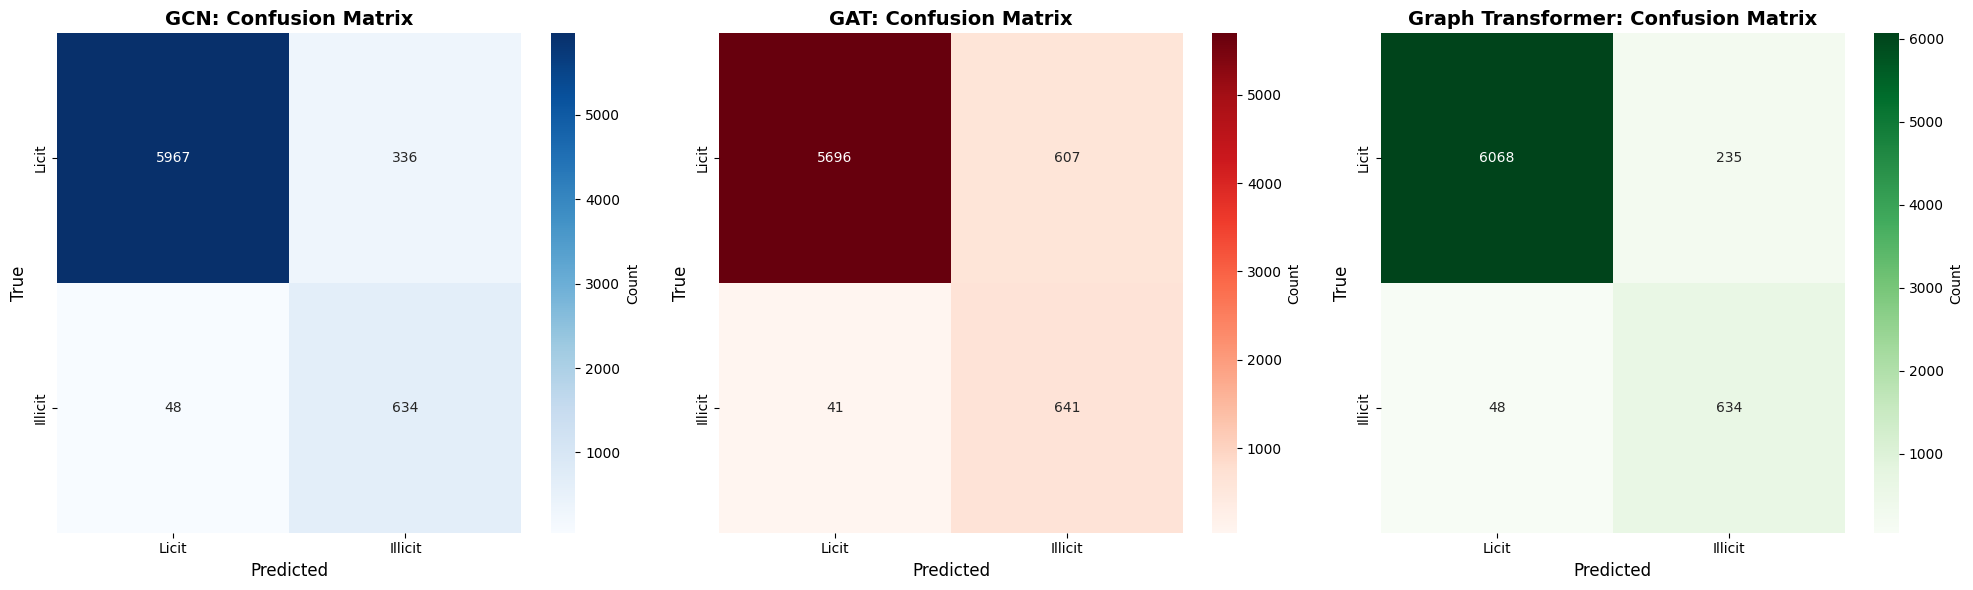


=== GCN Confusion Matrix ===
True Negatives (Licit predicted as Licit): 5967
False Positives (Licit predicted as Illicit): 336
False Negatives (Illicit predicted as Licit): 48
True Positives (Illicit predicted as Illicit): 634

=== GAT Confusion Matrix ===
True Negatives (Licit predicted as Licit): 5696
False Positives (Licit predicted as Illicit): 607
False Negatives (Illicit predicted as Licit): 41
True Positives (Illicit predicted as Illicit): 641

=== Graph Transformer Confusion Matrix ===
True Negatives (Licit predicted as Licit): 6068
False Positives (Licit predicted as Illicit): 235
False Negatives (Illicit predicted as Licit): 48
True Positives (Illicit predicted as Illicit): 634


In [53]:
from sklearn.metrics import confusion_matrix

# Generate confusion matrices
@torch.no_grad()
def get_confusion_matrix(model, data, mask):
    model.eval()
    logits = model(data.x, data.edge_index)
    preds = logits[mask].argmax(dim=-1).cpu().numpy()
    true = data.y[mask].cpu().numpy()
    return confusion_matrix(true, preds)

gcn_cm = get_confusion_matrix(gcn, data, data.test_mask)
gat_cm = get_confusion_matrix(gat, data, data.test_mask)
transformer_cm = get_confusion_matrix(transformer, data, data.test_mask)

# Plot confusion matrices
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

# GCN Confusion Matrix
sns.heatmap(gcn_cm, annot=True, fmt='d', cmap='Blues', ax=ax1, 
            xticklabels=['Licit', 'Illicit'], 
            yticklabels=['Licit', 'Illicit'],
            cbar_kws={'label': 'Count'})
ax1.set_xlabel('Predicted', fontsize=12)
ax1.set_ylabel('True', fontsize=12)
ax1.set_title('GCN: Confusion Matrix', fontsize=14, fontweight='bold')

# GAT Confusion Matrix
sns.heatmap(gat_cm, annot=True, fmt='d', cmap='Reds', ax=ax2,
            xticklabels=['Licit', 'Illicit'], 
            yticklabels=['Licit', 'Illicit'],
            cbar_kws={'label': 'Count'})
ax2.set_xlabel('Predicted', fontsize=12)
ax2.set_ylabel('True', fontsize=12)
ax2.set_title('GAT: Confusion Matrix', fontsize=14, fontweight='bold')

# Transformer Confusion Matrix
sns.heatmap(transformer_cm, annot=True, fmt='d', cmap='Greens', ax=ax3,
            xticklabels=['Licit', 'Illicit'], 
            yticklabels=['Licit', 'Illicit'],
            cbar_kws={'label': 'Count'})
ax3.set_xlabel('Predicted', fontsize=12)
ax3.set_ylabel('True', fontsize=12)
ax3.set_title('Graph Transformer: Confusion Matrix', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Print additional metrics
print("\n=== GCN Confusion Matrix ===")
print(f"True Negatives (Licit predicted as Licit): {gcn_cm[0,0]}")
print(f"False Positives (Licit predicted as Illicit): {gcn_cm[0,1]}")
print(f"False Negatives (Illicit predicted as Licit): {gcn_cm[1,0]}")
print(f"True Positives (Illicit predicted as Illicit): {gcn_cm[1,1]}")

print("\n=== GAT Confusion Matrix ===")
print(f"True Negatives (Licit predicted as Licit): {gat_cm[0,0]}")
print(f"False Positives (Licit predicted as Illicit): {gat_cm[0,1]}")
print(f"False Negatives (Illicit predicted as Licit): {gat_cm[1,0]}")
print(f"True Positives (Illicit predicted as Illicit): {gat_cm[1,1]}")

print("\n=== Graph Transformer Confusion Matrix ===")
print(f"True Negatives (Licit predicted as Licit): {transformer_cm[0,0]}")
print(f"False Positives (Licit predicted as Illicit): {transformer_cm[0,1]}")
print(f"False Negatives (Illicit predicted as Licit): {transformer_cm[1,0]}")
print(f"True Positives (Illicit predicted as Illicit): {transformer_cm[1,1]}")

Text(0.5, 0, 'Epoch')

Text(0, 0.5, 'Loss')

Text(0.5, 1.0, 'GCN: Training Loss vs Epoch')

Text(0.5, 0, 'Epoch')

Text(0, 0.5, 'Loss')

Text(0.5, 1.0, 'GAT: Training Loss vs Epoch')

Text(0.5, 0, 'Epoch')

Text(0, 0.5, 'Loss')

Text(0.5, 1.0, 'Graph Transformer: Training Loss vs Epoch')

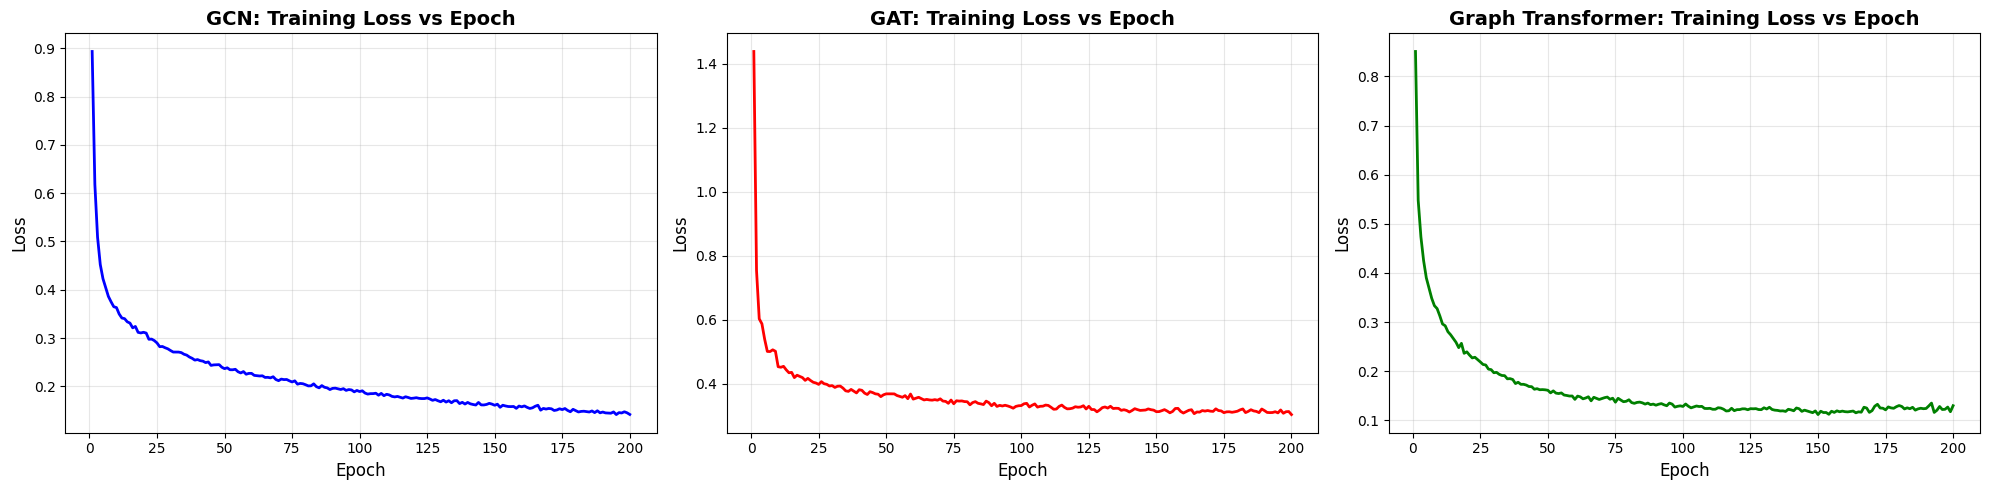

In [54]:
# Plot Epoch vs Loss graphs
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 5))

# GCN Loss
ax1.plot(range(1, len(gcn_loss_history) + 1), gcn_loss_history, 'b-', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('GCN: Training Loss vs Epoch', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# GAT Loss
ax2.plot(range(1, len(gat_loss_history) + 1), gat_loss_history, 'r-', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.set_title('GAT: Training Loss vs Epoch', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Transformer Loss
ax3.plot(range(1, len(transformer_loss_history) + 1), transformer_loss_history, 'g-', linewidth=2)
ax3.set_xlabel('Epoch', fontsize=12)
ax3.set_ylabel('Loss', fontsize=12)
ax3.set_title('Graph Transformer: Training Loss vs Epoch', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()